# Pedestrian Detection with Spiking ResNet-FPN

### Architecture Upgrade: Plain SNN → Spiking ResNet + Feature Pyramid Network

| Component | Original | This Notebook |
|---|---|---|
| **Backbone** | 3 plain Conv+LIF layers | Spiking ResNet (3 stages, residual blocks + BN) |
| **Beta** | Fixed scalar (0.85) | Learnable per-neuron (adaptive temporal dynamics) |
| **Detection** | Single grid, 1 raw box/cell | FPN × 2 scales, 3 YOLO anchors/scale |
| **Loss** | Equal BCE + MSE | Weighted obj/noobj + YOLO offset MSE |
| **Inference** | Threshold logit | Decode YOLO offsets → NMS |
| **Optimizer** | Adam | AdamW + Cosine Annealing scheduler |
| **Timesteps** | 5 | 8 (richer spike-rate encoding) |

### Key architectural references
- **EMS-ResNet membrane shortcut** — adds skip to pre-LIF membrane input, preserving gradient flow through depth  
- **YOLOv3-style anchor matching** — each GT box is matched to its best-IOU anchor; predictions are bounded offsets  
- **FPN top-down pathway** — fuses coarse (C4, 16×16) semantics into fine (C3, 32×32) spatial features


## 1. Imports

In [43]:
import os
import xml.etree.ElementTree as ET
import numpy as np
from PIL import Image
from torch.utils.data import Dataset, DataLoader, random_split
import torchvision.transforms as transforms
import torch
import torch.nn as nn
import torch.nn.functional as F
import snntorch as snn
from snntorch import surrogate


## 2. Global Configurations & Hyperparameters

Key changes vs. original:
- `NUM_STEPS 8` — more timesteps → denser spike-rate code, smoother gradients  
- `BATCH_SIZE 16` — reduced because the ResNet-FPN uses more memory than the original 3-layer net  
- `ANCHORS_P3 / ANCHORS_P4` — 6 pedestrian-tuned anchor boxes (normalized [0,1])  
  - **P3** (32×32 grid, 8 px/cell) targets small/close pedestrians  
  - **P4** (16×16 grid, 16 px/cell) targets large/far pedestrians  
  - Aspect ratios are tall-and-narrow, matching typical pedestrian shapes


In [44]:
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"Running on: {device}")

# ── Paths ──────────────────────────────────────────────────────────────────────
TRAIN_DIR   = "data/train"
FRAMES_DIR  = os.path.join(TRAIN_DIR, "Pedestrian frame")
LABELS_DIR  = os.path.join(TRAIN_DIR, "Pedestrian label")

# ── SNN hyperparameters ────────────────────────────────────────────────────────
NUM_STEPS  = 8     # ↑ vs original 5: richer temporal coding
BATCH_SIZE = 16    # ↓ vs original 128: ResNet-FPN is deeper
NUM_EPOCHS = 20
LR         = 1e-3

# ── Image / Dataset constants ──────────────────────────────────────────────────
IMG_SIZE = 256
ORIG_W   = 346     # Native dataset width
ORIG_H   = 260     # Native dataset height

# ── Anchor definitions (normalized [0,1]) ─────────────────────────────────────
# 3 anchors per scale, aspect ratios tuned for standing pedestrians
NUM_ANCHORS = 3
ANCHORS_P3  = [(0.05, 0.15), (0.09, 0.28), (0.14, 0.42)]   # small scale
ANCHORS_P4  = [(0.20, 0.55), (0.30, 0.70), (0.42, 0.90)]   # large scale


Running on: cuda


## 3. Neuromorphic Dataset Management

Dataset class is identical to the original — the Pascal VOC XML parsing, lazy
loading, and target dict format are unchanged.  
One addition: **ImageNet normalization** in the transform pipeline, which
improves gradient flow when training the BatchNorm layers inside the backbone.


In [45]:
from dataset_helper import PedestrianDataset, collate_fn

In [46]:
# class PedestrianDataset(Dataset):
#     def __init__(self, frames_dir, labels_dir, transform=None):
#         self.frames_dir = frames_dir
#         self.labels_dir = labels_dir
#         self.transform  = transform
#         self.filenames  = []

#         for f in sorted(os.listdir(frames_dir)):
#             if f.endswith('.png'):
#                 base = os.path.splitext(f)[0]
#                 if os.path.exists(os.path.join(labels_dir, f"{base}.xml")):
#                     self.filenames.append(base)

#         print(f"Matched {len(self.filenames)} image/label pairs.")

#     def __len__(self):
#         return len(self.filenames)

#     def parse_xml(self, xml_path, idx):
#         root   = ET.parse(xml_path).getroot()
#         boxes, labels, areas = [], [], []
#         for obj in root.findall('object'):
#             if obj.find('name').text == 'person':
#                 labels.append(1)
#                 bb   = obj.find('bndbox')
#                 xmin = float(bb.find('xmin').text)
#                 ymin = float(bb.find('ymin').text)
#                 xmax = float(bb.find('xmax').text)
#                 ymax = float(bb.find('ymax').text)
#                 boxes.append([xmin, ymin, xmax, ymax])
#                 areas.append((xmax - xmin) * (ymax - ymin))
#         return {
#             "boxes":    torch.as_tensor(boxes,  dtype=torch.float32),
#             "labels":   torch.as_tensor(labels, dtype=torch.int64),
#             "image_id": torch.tensor([idx],     dtype=torch.int64),
#             "area":     torch.as_tensor(areas,  dtype=torch.float32),
#             "iscrowd":  torch.zeros(len(labels), dtype=torch.int64),
#         }

#     def __getitem__(self, idx):
#         base   = self.filenames[idx]
#         image  = Image.open(os.path.join(self.frames_dir, f"{base}.png")).convert("RGB")
#         target = self.parse_xml(os.path.join(self.labels_dir, f"{base}.xml"), idx)
#         if self.transform:
#             image = self.transform(image)
#         return image, target


# def collate_fn(batch):
#     return tuple(zip(*batch))


In [47]:
# ImageNet normalization added to match BatchNorm expectations in the new backbone
image_transforms = transforms.Compose([
    transforms.Resize((IMG_SIZE, IMG_SIZE)),
    transforms.ToTensor(),
    transforms.Normalize(mean=[0.485, 0.456, 0.406],
                         std =[0.229, 0.224, 0.225]),
])

# Ensure child processes don't execute this block when spawned
if __name__ == '__main__':
    dataset = PedestrianDataset(FRAMES_DIR, LABELS_DIR, transform=image_transforms)
    train_size = int(0.8 * len(dataset))
    test_size = len(dataset) - train_size

    generator = torch.Generator().manual_seed(42)
    train_dataset, test_dataset = random_split(dataset, [train_size, test_size],
                                               generator=generator)

    # Change num_workers here safely (2 or 4 is ideal for most 4060 laptops)
    train_loader = DataLoader(train_dataset, batch_size=BATCH_SIZE, shuffle=True,
                              num_workers=2, collate_fn=collate_fn, pin_memory=True, persistent_workers=True)
    test_loader  = DataLoader(test_dataset,  batch_size=BATCH_SIZE, shuffle=False,
                              num_workers=2, collate_fn=collate_fn, pin_memory=True, persistent_workers=True)

    print(f"Total: {len(dataset)} | Train: {len(train_dataset)} | Test: {len(test_dataset)}")


Total: 4119 | Train: 3295 | Test: 824


## 4. Spiking ResNet-FPN Architecture

### 4.1 Spiking Residual Block (`SpikingResBlock`)

**Membrane shortcut** (EMS-ResNet, 2023):  
The skip connection is added to the _pre-LIF current_, not the spike output.  
This means the recurrent membrane equation becomes:

$$\text{mem}[t] = \beta \cdot \text{mem}[t-1] + \underbrace{(\text{Conv}_2(\text{spk}_1) + \text{skip}(x))}_{\text{membrane shortcut}}$$

Compared to the naive approach (adding skip to spike output, which is binary),
this preserves continuous gradient signal through residual paths.

**Learnable beta**: `learn_beta=True` makes each LIF neuron's decay constant a  
trainable parameter, initialized to 0.9 and optimized end-to-end.


In [48]:
class SpikingResBlock(nn.Module):
    """
    Spiking Residual Block with membrane shortcut.
    Each block manages two LIF neurons (lif1, lif2) whose membrane
    potentials are passed in and out explicitly across time steps.
    """
    def __init__(self, in_ch, out_ch, stride=1, spike_grad=None):
        super().__init__()
        self.conv1 = nn.Conv2d(in_ch, out_ch, 3, stride=stride, padding=1, bias=False)
        self.bn1   = nn.BatchNorm2d(out_ch)
        self.lif1  = snn.Leaky(beta=0.9, spike_grad=spike_grad, learn_beta=True)

        self.conv2 = nn.Conv2d(out_ch, out_ch, 3, padding=1, bias=False)
        self.bn2   = nn.BatchNorm2d(out_ch)
        self.lif2  = snn.Leaky(beta=0.9, spike_grad=spike_grad, learn_beta=True)

        # Projection shortcut: 1×1 conv to match dimensions if needed
        self.skip = nn.Sequential()
        if stride != 1 or in_ch != out_ch:
            self.skip = nn.Sequential(
                nn.Conv2d(in_ch, out_ch, 1, stride=stride, bias=False),
                nn.BatchNorm2d(out_ch),
            )

    def forward(self, x, mem1, mem2):
        # Path 1: conv → BN → LIF
        spk1, mem1 = self.lif1(self.bn1(self.conv1(x)), mem1)
        # Path 2: conv → BN + skip(x) → LIF  (membrane shortcut)
        spk2, mem2 = self.lif2(self.bn2(self.conv2(spk1)) + self.skip(x), mem2)
        return spk2, mem1, mem2

    def init_mems(self):
        """Return zero membrane potentials for both LIF neurons."""
        return self.lif1.init_leaky(), self.lif2.init_leaky()


### 4.2 Full Spiking ResNet-FPN Detector (`SpikingFPNDetector`)

**Backbone** — 3 ResNet stages run inside a temporal loop (`NUM_STEPS` iterations):

```
Input 256×256
  └─ Stem (Conv-BN-LIF, stride 2) → 128×128, 32ch
     └─ Stage 1 (2× ResBlock, stride 2) → 64×64, 64ch
        └─ Stage 2 (2× ResBlock, stride 2) → C3: 32×32, 128ch
           └─ Stage 3 (2× ResBlock, stride 2) → C4: 16×16, 256ch
```

Spike maps at C3 and C4 are accumulated over all time steps and divided by
`NUM_STEPS` → spike-rate tensors in [0, 1].

**FPN Neck** (non-spiking, operates on spike-rate maps):
```
P4 = Conv(C4)                            → 16×16, 128ch
P3 = Conv(C3) + Upsample(P4, ×2)        → 32×32, 128ch
```

**Detection Heads** (two-scale):
```
head_p3(P3) → (B, 15, 32, 32)   per cell: 3 anchors × [obj, tx, ty, tw, th]
head_p4(P4) → (B, 15, 16, 16)
```


In [49]:
class SpikingFPNDetector(nn.Module):
    def __init__(self, num_steps=NUM_STEPS):
        super().__init__()
        self.num_steps = num_steps
        sg = surrogate.fast_sigmoid(slope=25)   # Surrogate gradient for BPTT

        # ── Spiking Backbone ──────────────────────────────────────────────────
        # Stem: 256×256 → 128×128, 32ch
        self.stem_conv = nn.Conv2d(3, 32, 3, stride=2, padding=1, bias=False)
        self.stem_bn   = nn.BatchNorm2d(32)
        self.stem_lif  = snn.Leaky(beta=0.9, spike_grad=sg, learn_beta=True)

        # Stage 1: 128×128 → 64×64, 64ch
        self.stage1 = nn.ModuleList([
            SpikingResBlock(32,  64, stride=2, spike_grad=sg),
            SpikingResBlock(64,  64, stride=1, spike_grad=sg),
        ])
        # Stage 2 (C3): 64×64 → 32×32, 128ch — used by FPN P3
        self.stage2 = nn.ModuleList([
            SpikingResBlock(64,  128, stride=2, spike_grad=sg),
            SpikingResBlock(128, 128, stride=1, spike_grad=sg),
        ])
        # Stage 3 (C4): 32×32 → 16×16, 256ch — used by FPN P4
        self.stage3 = nn.ModuleList([
            SpikingResBlock(128, 256, stride=2, spike_grad=sg),
            SpikingResBlock(256, 256, stride=1, spike_grad=sg),
        ])

        # ── FPN Neck (non-spiking; operates on accumulated spike rates) ───────
        self.lat_c4 = nn.Sequential(
            nn.Conv2d(256, 128, 1, bias=False), nn.BatchNorm2d(128), nn.ReLU(inplace=True))
        self.lat_c3 = nn.Sequential(
            nn.Conv2d(128, 128, 1, bias=False), nn.BatchNorm2d(128), nn.ReLU(inplace=True))
        self.out_p4 = nn.Sequential(
            nn.Conv2d(128, 128, 3, padding=1, bias=False), nn.BatchNorm2d(128), nn.ReLU(inplace=True))
        self.out_p3 = nn.Sequential(
            nn.Conv2d(128, 128, 3, padding=1, bias=False), nn.BatchNorm2d(128), nn.ReLU(inplace=True))

        # ── Detection Heads ───────────────────────────────────────────────────
        # Per anchor: [objectness logit, tx, ty, tw, th] → 5 values
        out_ch = NUM_ANCHORS * 5
        def _head(in_ch):
            return nn.Sequential(
                nn.Conv2d(in_ch, in_ch, 3, padding=1, bias=False),
                nn.BatchNorm2d(in_ch), nn.ReLU(inplace=True),
                nn.Conv2d(in_ch, out_ch, 1),
            )
        self.head_p3 = _head(128)   # predicts on 32×32 grid
        self.head_p4 = _head(128)   # predicts on 16×16 grid

    # ── Helpers ───────────────────────────────────────────────────────────────
    def _init_mems(self):
        return {
            'stem': self.stem_lif.init_leaky(),
            's1':   [blk.init_mems() for blk in self.stage1],
            's2':   [blk.init_mems() for blk in self.stage2],
            's3':   [blk.init_mems() for blk in self.stage3],
        }

    # ── Forward ───────────────────────────────────────────────────────────────
    def forward(self, x):
        mems   = self._init_mems()
        c3_acc = c4_acc = None

        # ── Temporal loop: run backbone NUM_STEPS times (static input) ────────
        for _ in range(self.num_steps):
            # Stem
            spk, mems['stem'] = self.stem_lif(
                self.stem_bn(self.stem_conv(x)), mems['stem'])

            # Stage 1
            for i, blk in enumerate(self.stage1):
                m1, m2 = mems['s1'][i]
                spk, m1, m2 = blk(spk, m1, m2)
                mems['s1'][i] = (m1, m2)

            # Stage 2 → C3
            for i, blk in enumerate(self.stage2):
                m1, m2 = mems['s2'][i]
                spk, m1, m2 = blk(spk, m1, m2)
                mems['s2'][i] = (m1, m2)
            c3 = spk

            # Stage 3 → C4
            for i, blk in enumerate(self.stage3):
                m1, m2 = mems['s3'][i]
                spk, m1, m2 = blk(spk, m1, m2)
                mems['s3'][i] = (m1, m2)
            c4 = spk

            # Accumulate binary spike maps
            c3_acc = c3 if c3_acc is None else c3_acc + c3
            c4_acc = c4 if c4_acc is None else c4_acc + c4

        # Normalize → spike-rate tensors ∈ [0, 1]
        c3_rate = c3_acc / self.num_steps   # (B, 128, 32, 32)
        c4_rate = c4_acc / self.num_steps   # (B, 256, 16, 16)

        # ── FPN top-down fusion ────────────────────────────────────────────────
        p4 = self.out_p4(self.lat_c4(c4_rate))
        p3 = self.out_p3(self.lat_c3(c3_rate) +
                         F.interpolate(p4, scale_factor=2, mode='nearest'))

        # ── Two-scale detection outputs ────────────────────────────────────────
        return self.head_p3(p3), self.head_p4(p4)
        #   pred_p3: (B, 15, 32, 32) — detects small/medium pedestrians
        #   pred_p4: (B, 15, 16, 16) — detects large pedestrians


## 5. Loss Functions

### Anchor matching
For each ground-truth box, the anchor with the highest IoU (at any scale) is
selected to be responsible for that prediction.  Only that cell/anchor receives
box-regression supervision.

### Target format (YOLO offsets)
- `tx, ty` — center offset _within_ the responsible cell, ∈ [0, 1]
- `tw, th` — log-scale offset relative to anchor size:  
  `tw = log(gt_w / anchor_w)`,  decoded as `w = anchor_w · exp(tw)`

### Loss weighting
| Term | Weight | Rationale |
|---|---|---|
| Objectness at positive cells | λ = 1.0 | Reward detection |
| Objectness at negative cells | λ = 0.5 | Background cells far outnumber objects |
| Box regression (tx,ty,tw,th) | λ = 5.0 | Localization is the hard part |


In [50]:
def _anchor_iou(box_wh, anc_wh):
    """IoU between two boxes centered at the same point (shape-only IoU)."""
    inter = min(box_wh[0], anc_wh[0]) * min(box_wh[1], anc_wh[1])
    union = box_wh[0]*box_wh[1] + anc_wh[0]*anc_wh[1] - inter
    return inter / (union + 1e-6)


def build_targets(targets, grid_h, grid_w, anchors, device):
    """
    Build the target tensor for one detection scale.
    Returns tensor of shape (B, NUM_ANCHORS*5, grid_h, grid_w).
    Channel layout per anchor a: [obj, tx, ty, tw, th] at offset a*5.
    """
    B   = len(targets)
    tgt = torch.zeros(B, NUM_ANCHORS * 5, grid_h, grid_w, device=device)

    for i, t in enumerate(targets):
        boxes = t["boxes"]
        if boxes.shape[0] == 0:
            continue

        for box in boxes:
            xmin = box[0].item() / ORIG_W
            ymin = box[1].item() / ORIG_H
            xmax = box[2].item() / ORIG_W
            ymax = box[3].item() / ORIG_H

            cx  = (xmin + xmax) / 2.0
            cy  = (ymin + ymax) / 2.0
            bw  = xmax - xmin
            bh  = ymax - ymin

            # Grid cell responsible for this object's center
            gx = min(int(cx * grid_w), grid_w - 1)
            gy = min(int(cy * grid_h), grid_h - 1)

            # Assign to the best-matching anchor (highest shape IoU)
            best_a = max(range(NUM_ANCHORS),
                         key=lambda a: _anchor_iou((bw, bh), anchors[a]))
            aw, ah = anchors[best_a]

            # YOLO-style offset targets
            tx = cx * grid_w - gx           # in-cell offset [0,1]
            ty = cy * grid_h - gy
            tw = np.log(max(bw / aw, 1e-6)) # log-scale wrt anchor
            th = np.log(max(bh / ah, 1e-6))

            b = best_a * 5
            tgt[i, b + 0, gy, gx] = 1.0    # objectness
            tgt[i, b + 1, gy, gx] = tx
            tgt[i, b + 2, gy, gx] = ty
            tgt[i, b + 3, gy, gx] = tw
            tgt[i, b + 4, gy, gx] = th

    return tgt


def compute_loss(pred_p3, pred_p4, targets, device,
                 lam_obj=1.0, lam_noobj=0.5, lam_box=5.0):
    """
    Combined multi-scale detection loss.
    Loops over both FPN scales and all anchors within each scale.
    """
    _, _, H3, W3 = pred_p3.shape
    _, _, H4, W4 = pred_p4.shape

    tgt_p3 = build_targets(targets, H3, W3, ANCHORS_P3, device)
    tgt_p4 = build_targets(targets, H4, W4, ANCHORS_P4, device)

    total = torch.tensor(0.0, device=device)

    for pred, tgt in [(pred_p3, tgt_p3), (pred_p4, tgt_p4)]:
        for a in range(NUM_ANCHORS):
            b = a * 5
            pred_obj = pred[:, b,     :, :]
            true_obj = tgt[:,  b,     :, :]

            pos = true_obj == 1.0
            neg = ~pos

            # Objectness: separate positive / negative to handle imbalance
            if pos.sum() > 0:
                total += lam_obj * F.binary_cross_entropy_with_logits(
                    pred_obj[pos], true_obj[pos])
            if neg.sum() > 0:
                total += lam_noobj * F.binary_cross_entropy_with_logits(
                    pred_obj[neg], true_obj[neg])

            # Box regression only at positive cells
            if pos.sum() > 0:
                for off in range(1, 5):
                    p = pred[:, b + off, :, :][pos]
                    t = tgt[:,  b + off, :, :][pos]
                    total += lam_box * F.mse_loss(p, t)

    return total


## 6. Model Training Pipeline

Two optimizer upgrades vs. original:
- **AdamW** — decoupled weight decay prevents the L2 penalty from interacting
  with the adaptive learning rates, which benefits BatchNorm-heavy models.
- **CosineAnnealingLR** — smoothly decays LR to near-zero over training,
  reducing oscillations around the minimum in late epochs.

**Gradient clipping** (`max_norm=10.0`) prevents rare membrane-potential
explosions that can occur in deeper SNN graphs during early training.


In [51]:
model = SpikingFPNDetector(num_steps=NUM_STEPS).to(device)

optimizer = torch.optim.AdamW(model.parameters(), lr=LR, weight_decay=1e-4)
scheduler = torch.optim.lr_scheduler.CosineAnnealingLR(
    optimizer, T_max=NUM_EPOCHS, eta_min=1e-5)

total_params = sum(p.numel() for p in model.parameters() if p.requires_grad)
print(f"Trainable parameters: {total_params:,}")
print(f"Device: {device} | Timesteps: {NUM_STEPS} | Epochs: {NUM_EPOCHS}")


Trainable parameters: 3,402,315
Device: cuda | Timesteps: 8 | Epochs: 20


In [52]:
# Your training loop cell modification
if __name__ == '__main__':
    for epoch in range(NUM_EPOCHS):
        model.train()
        epoch_loss = 0.0

        for images, targets in train_loader:
            if isinstance(images, (tuple, list)):
                images = torch.stack(images).to(device)

            pred_p3, pred_p4 = model(images)
            loss = compute_loss(pred_p3, pred_p4, targets, device)

            optimizer.zero_grad()
            loss.backward()
            torch.nn.utils.clip_grad_norm_(model.parameters(), max_norm=10.0)
            optimizer.step()

            epoch_loss += loss.item()

        scheduler.step()
        current_lr = scheduler.get_last_lr()[0]
        print(f"Epoch [{epoch+1:02d}/{NUM_EPOCHS}] | Loss: {epoch_loss:.4f} | LR: {current_lr:.2e}")


Epoch [01/20] | Loss: 1300.0627 | LR: 9.94e-04
Epoch [02/20] | Loss: 862.4518 | LR: 9.76e-04
Epoch [03/20] | Loss: 770.8639 | LR: 9.46e-04
Epoch [04/20] | Loss: 722.4916 | LR: 9.05e-04
Epoch [05/20] | Loss: 686.4963 | LR: 8.55e-04
Epoch [06/20] | Loss: 647.3314 | LR: 7.96e-04
Epoch [07/20] | Loss: 603.6747 | LR: 7.30e-04
Epoch [08/20] | Loss: 567.8751 | LR: 6.58e-04
Epoch [09/20] | Loss: 533.5054 | LR: 5.82e-04
Epoch [10/20] | Loss: 501.1197 | LR: 5.05e-04
Epoch [11/20] | Loss: 474.8367 | LR: 4.28e-04
Epoch [12/20] | Loss: 448.9788 | LR: 3.52e-04
Epoch [13/20] | Loss: 414.4744 | LR: 2.80e-04
Epoch [14/20] | Loss: 383.0686 | LR: 2.14e-04
Epoch [15/20] | Loss: 359.1183 | LR: 1.55e-04
Epoch [16/20] | Loss: 333.8960 | LR: 1.05e-04
Epoch [17/20] | Loss: 307.0366 | LR: 6.40e-05
Epoch [18/20] | Loss: 289.8034 | LR: 3.42e-05
Epoch [19/20] | Loss: 276.7104 | LR: 1.61e-05
Epoch [20/20] | Loss: 267.4971 | LR: 1.00e-05


## 7. Performance Evaluation & Metrics

### Inference pipeline
```
pred_p3, pred_p4 = model(image)
    ↓
decode_predictions()          # YOLO offset → (conf, xmin, ymin, xmax, ymax)
    ↓  (both scales combined)
nms()                         # suppress duplicates, keep highest-conf boxes
    ↓
evaluate against GT boxes
```

### Decoding YOLO offsets
For anchor `a` at cell `(gx, gy)` with grid `(W, H)`:

$$c_x = \frac{g_x + \sigma(t_x)}{W}, \quad c_y = \frac{g_y + \sigma(t_y)}{H}$$
$$w = a_w \cdot e^{t_w}, \quad h = a_h \cdot e^{t_h}$$

`exp(tw)` is clipped to `[-4, 4]` to prevent runaway box sizes early in training.

### Metrics
- **Pedestrian Presence Accuracy** — frame-level binary: did the model correctly
  detect whether any pedestrian is present?  
- **Mean Box IoU** — for each ground-truth box, the best IoU among all predicted
  boxes after NMS.


In [71]:
def calculate_iou(boxA, boxB):
    """IoU between two boxes in [xmin,ymin,xmax,ymax] format."""
    xA = max(boxA[0], boxB[0]); yA = max(boxA[1], boxB[1])
    xB = min(boxA[2], boxB[2]); yB = min(boxA[3], boxB[3])
    inter = max(0.0, xB - xA) * max(0.0, yB - yA)
    uA    = (boxA[2]-boxA[0]) * (boxA[3]-boxA[1])
    uB    = (boxB[2]-boxB[0]) * (boxB[3]-boxB[1])
    return inter / float(uA + uB - inter) if (uA + uB - inter) > 0 else 0.0


def decode_predictions(pred, anchors, grid_h, grid_w, conf_thresh=0.4):
    """
    Corrected decoding function to match build_targets coordinate scale perfectly.
    """
    results = []
    for a_idx, (aw, ah) in enumerate(anchors):
        b        = a_idx * 5
        conf_map = torch.sigmoid(pred[b])                    # (H, W)
        gy_idx, gx_idx = torch.where(conf_map >= conf_thresh)

        for gy, gx in zip(gy_idx.tolist(), gx_idx.tolist()):
            conf = conf_map[gy, gx].item()
            
            # Undo sigmoid/raw outputs to match targets exactly
            tx   = torch.sigmoid(pred[b+1, gy, gx]).item()  
            ty   = torch.sigmoid(pred[b+2, gy, gx]).item()
            tw   = float(np.clip(pred[b+3, gy, gx].item(), -4, 4))
            th   = float(np.clip(pred[b+4, gy, gx].item(), -4, 4))

            # MATCHING FIX: Convert grid offsets back to global image space [0, 1]
            cx   = (gx + tx) / grid_w
            cy   = (gy + ty) / grid_h
            
            # aw and ah are already in global image space [0, 1]
            w    = aw * np.exp(tw)
            h    = ah * np.exp(th)

            xmin = max(0.0, cx - w / 2)
            ymin = max(0.0, cy - h / 2)
            xmax = min(1.0, cx + w / 2)
            ymax = min(1.0, cy + h / 2)
            results.append((conf, xmin, ymin, xmax, ymax))

    return results


def nms(boxes, iou_thresh=0.45):
    """
    Non-Maximum Suppression.
    Iteratively keeps the highest-confidence box and suppresses overlapping ones.
    boxes: list of (conf, xmin, ymin, xmax, ymax)
    """
    if not boxes:
        return []
    boxes = sorted(boxes, key=lambda b: b[0], reverse=True)
    kept  = []
    while boxes:
        best = boxes.pop(0)
        kept.append(best)
        boxes = [b for b in boxes
                 if calculate_iou(best[1:], b[1:]) < iou_thresh]
    return kept


In [75]:
def evaluate(model, loader, device, conf_thresh=0.6, iou_thresh=0.2):
    """
    Full evaluation loop.
    Decodes predictions from both FPN scales, applies NMS, then
    measures frame-level presence accuracy and per-box mean IoU.
    """
    model.eval()
    total_imgs       = 0
    correct_cls      = 0
    total_iou        = 0.0
    total_true_boxes = 0

    with torch.no_grad():
        for images, targets in loader:
            if isinstance(images, (tuple, list)):
                images = torch.stack(images).to(device)

            pred_p3, pred_p4 = model(images)

            for i in range(len(targets)):
                total_imgs   += 1
                true_boxes    = targets[i]["boxes"].cpu().numpy()
                actual_has    = len(true_boxes) > 0

                # Decode both scales and merge before NMS
                raw = (decode_predictions(pred_p3[i].cpu(), ANCHORS_P3,
                                          32, 32, conf_thresh) +
                       decode_predictions(pred_p4[i].cpu(), ANCHORS_P4,
                                          16, 16, conf_thresh))
                pred_boxes = nms(raw, iou_thresh)
                pred_has   = len(pred_boxes) > 0

                if actual_has == pred_has:
                    correct_cls += 1

                if actual_has:
                    for tb in true_boxes:
                        total_true_boxes += 1
                        tb_n = [tb[0]/ORIG_W, tb[1]/ORIG_H,
                                tb[2]/ORIG_W, tb[3]/ORIG_H]
                        best = max(
                            (calculate_iou(tb_n, pb[1:]) for pb in pred_boxes),
                            default=0.0)
                        total_iou += best

    cls_acc = correct_cls / total_imgs * 100
    avg_iou = (total_iou / total_true_boxes * 100
               if total_true_boxes > 0 else 0.0)

    print("\n══════════════ TEST RESULTS ══════════════")
    print(f"  Evaluated Images:          {total_imgs}")
    print(f"  Pedestrian Presence Acc:   {cls_acc:.2f}%")
    print(f"  Mean Box IoU:              {avg_iou:.2f}%")
    print("══════════════════════════════════════════")
    return cls_acc, avg_iou


In [76]:
evaluate(model, test_loader, device)



══════════════ TEST RESULTS ══════════════
  Evaluated Images:          824
  Pedestrian Presence Acc:   94.42%
  Mean Box IoU:              51.33%
══════════════════════════════════════════


(94.41747572815534, np.float64(51.331169393528086))

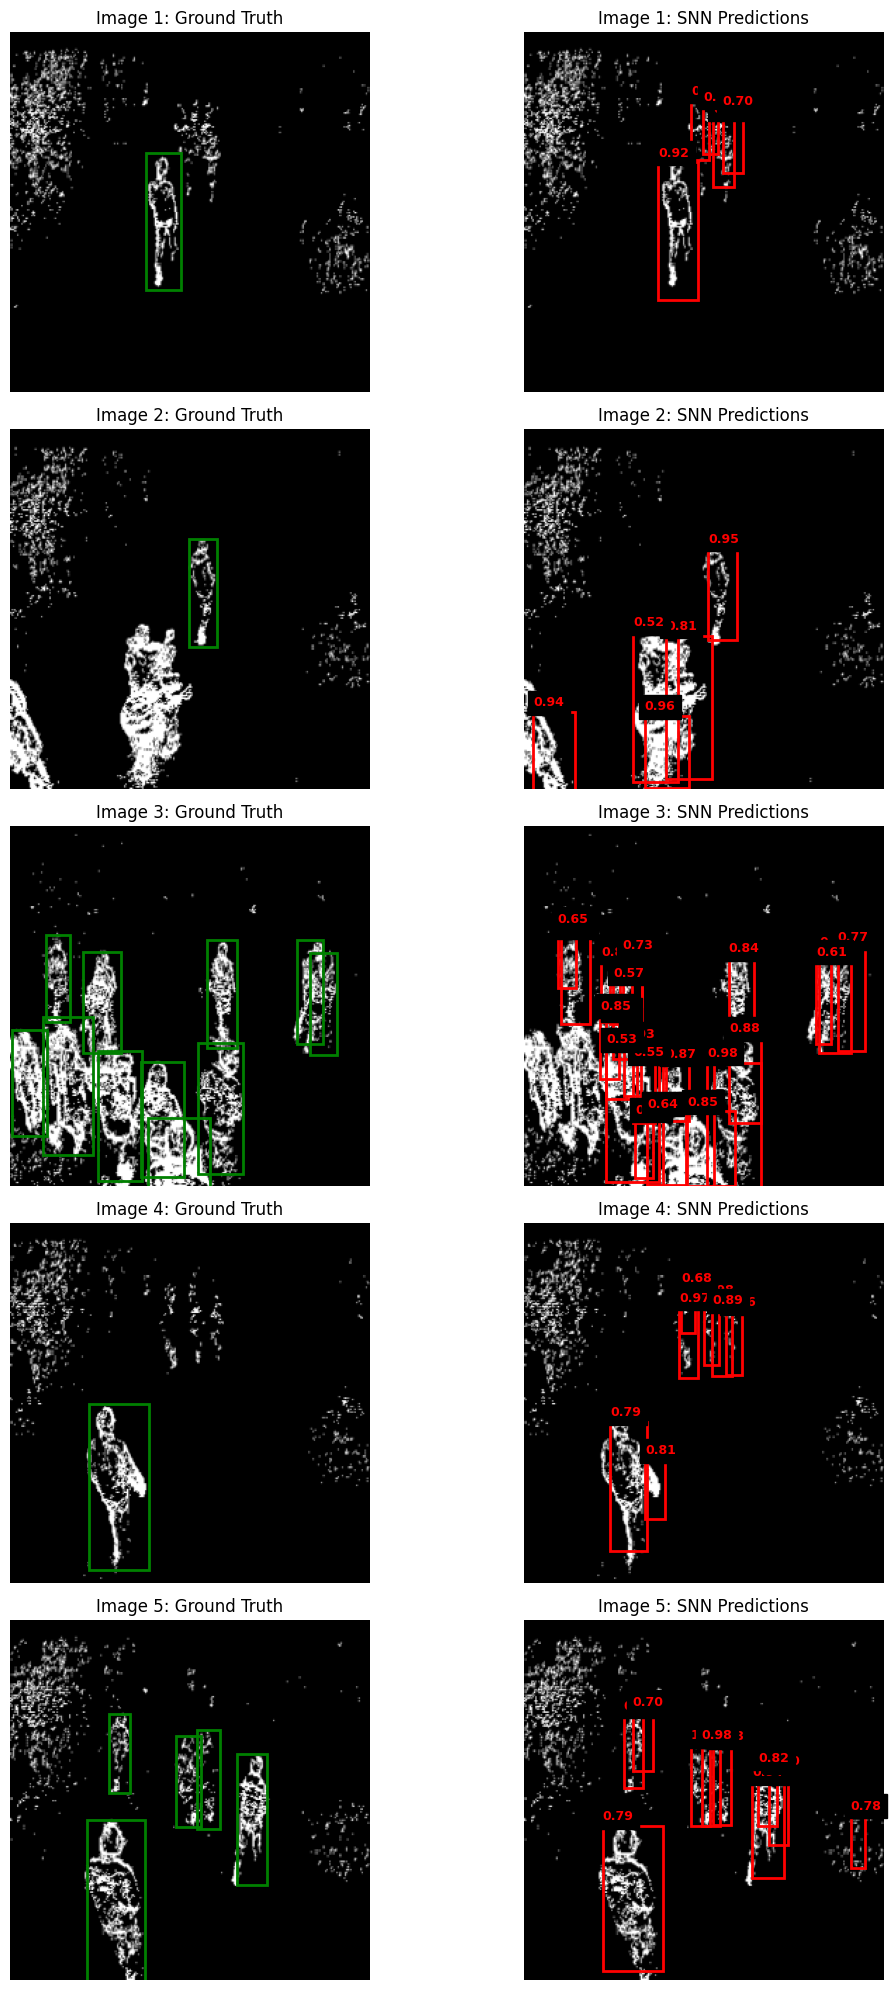

In [77]:
import matplotlib.pyplot as plt
import matplotlib.patches as patches
import random

def visualize_test_predictions(model, loader, device, num_images=5, conf_thresh=0.5, iou_thresh=0.3):
    """
    Takes random samples from the test loader, runs inference, 
    and plots Ground Truth vs Model Predictions side-by-side.
    """
    model.eval()
    all_samples = []
    
    # Gather all images and targets from the loader to choose truly random ones
    with torch.no_grad():
        for images, targets in loader:
            for i in range(len(targets)):
                all_samples.append((images[i], targets[i]))
                
    # Randomly select the requested number of images
    samples = random.sample(all_samples, min(num_images, len(all_samples)))
    
    # Create a grid layout: 2 columns (GT vs Pred) x num_images rows
    fig, axs = plt.subplots(num_images, 2, figsize=(12, 4 * num_images))
    if num_images == 1:
        axs = np.expand_dims(axs, axis=0) # Ensure axs is 2D if only 1 image
        
    for idx, (img_tensor, target) in enumerate(samples):
        # 1. Prepare image for plotting (Denormalize from ImageNet stats)
        # img_tensor shape: (3, 256, 256)
        mean = torch.tensor([0.485, 0.456, 0.406]).view(3, 1, 1)
        std = torch.tensor([0.229, 0.224, 0.225]).view(3, 1, 1)
        img_plot = img_tensor.cpu() * std + mean
        img_plot = torch.clamp(img_plot, 0, 1).permute(1, 2, 0).numpy()
        
        # 2. Run model inference
        # Add batch dimension and move to device -> (1, 3, 256, 256)
        img_input = img_tensor.unsqueeze(0).to(device) 
        pred_p3, pred_p4 = model(img_input)
        
        # Decode and merge predictions from both scales
        raw_preds = (
            decode_predictions(pred_p3[0].cpu(), ANCHORS_P3, 32, 32, conf_thresh) +
            decode_predictions(pred_p4[0].cpu(), ANCHORS_P4, 16, 16, conf_thresh)
        )
        final_preds = nms(raw_preds, iou_thresh)
        
        # ─── LEFT COLUMN: GROUND TRUTH ────────────────────────────────────────
        ax_gt = axs[idx, 0]
        ax_gt.imshow(img_plot)
        ax_gt.set_title(f"Image {idx+1}: Ground Truth")
        ax_gt.axis('off')
        
        true_boxes = target["boxes"].cpu().numpy()
        for box in true_boxes:
            # Scale coordinates from native resolution back to the 256x256 display space
            xmin = (box[0] / ORIG_W) * IMG_SIZE
            ymin = (box[1] / ORIG_H) * IMG_SIZE
            xmax = (box[2] / ORIG_W) * IMG_SIZE
            ymax = (box[3] / ORIG_H) * IMG_SIZE
            
            rect = patches.Rectangle((xmin, ymin), xmax - xmin, ymax - ymin,
                                     linewidth=2, edgecolor='g', facecolor='none')
            ax_gt.add_patch(rect)
            
        # ─── RIGHT COLUMN: MODEL PREDICTIONS ──────────────────────────────────
        ax_pred = axs[idx, 1]
        ax_pred.imshow(img_plot)
        ax_pred.set_title(f"Image {idx+1}: SNN Predictions")
        ax_pred.axis('off')
        
        for conf, xmin, ymin, xmax, ymax in final_preds:
            # Predictions are already normalized [0,1], scale up to 256x256 display space
            x1, y1 = xmin * IMG_SIZE, ymin * IMG_SIZE
            w, h = (xmax - xmin) * IMG_SIZE, (ymax - ymin) * IMG_SIZE
            
            rect = patches.Rectangle((x1, y1), w, h, linewidth=2, edgecolor='r', facecolor='none')
            ax_pred.add_patch(rect)
            
            # Label with confidence score
            ax_pred.text(x1, y1 - 4, f"{conf:.2f}", color='red',
                         fontsize=9, weight='bold', backgroundcolor='black')
            
    plt.tight_layout()
    plt.show()

# Run the visualizer (change 5 to 10 if you want to inspect more images)
visualize_test_predictions(model, test_loader, device, num_images=5)

## Weights backup

This code snippets saves the model weights that can then be loaded back so that you don't need to train again the model.

The weights loading code still needs to be implemented.

In [ ]:
# from datetime import datetime

# # 1. Create a timestamp string (Format: YYYYMMDD_HHMMSS)
# timestamp = datetime.now().strftime("%Y%m%d_%H%M%S")

# # 2. Define the filename with the timestamp appended
# model_filename = f"spiking_resnet_fpn_{timestamp}.pt"

# # 3. Create a directory to store models if it doesn't exist yet
# os.makedirs("saved_models", exist_ok=True)
# save_path = os.path.join("saved_models", model_filename)

# # 4. Save the model's state_dict
# torch.save(model.state_dict(), save_path)

# print(f"Model successfully saved to: {save_path}")

Model successfully saved to: saved_models\spiking_resnet_fpn_20260613_030717.pt
